# RamanBench — Quick Start

This notebook introduces the RamanBench ecosystem and shows the fastest path to exploring results.

## Ecosystem

| Resource                       | Link                                                                                               |
|--------------------------------|----------------------------------------------------------------------------------------------------|
| **raman-data** (datasets)      | [GitHub](https://github.com/ml-lab-htw/raman_data) · [PyPI](https://pypi.org/project/raman-data/)  |
| **raman-bench** (this package) | [GitHub](https://github.com/ml-lab-htw/RamanBench) · [PyPI](https://pypi.org/project/raman-bench/) |
| **Live Leaderboard**           | [HuggingFace Space](https://huggingface.co/spaces/ml-lab-htw/RamanBench)                           |
| **Paper**                      | [arXiv TBD](https://arxiv.org/abs/TBD)                                                             |

In [1]:
# Install if not already installed
# !pip install raman-bench raman-data

## 1. Load a Raman dataset

In [2]:
from raman_data import raman_data

# Load a regression dataset (amino acid concentrations)
dataset = raman_data('amino_acids_glycine')

print(f'Dataset: {dataset.name}')
print(f'Spectra shape: {dataset.spectra.shape}  (samples × wavenumbers)')
print(f'Targets shape: {dataset.targets.shape}')
print(f'Target names: {dataset.target_names}')
print(f'Spectral range: {dataset.raman_shifts.min():.0f}–{dataset.raman_shifts.max():.0f} cm⁻¹')

2026-04-27 09:25:48,094 INFO raman_data:raman_data:50: Loading dataset: amino_acids_glycine (cache_dir=None)
2026-04-27 09:25:48,095 INFO raman_data.loaders.KaggleLoader:load_dataset:381: Loading Kaggle dataset 'amino_acids_glycine' from default folder (~/.cache/kagglehub)


Dataset: Amino Acid LC (Glycine)
Spectra shape: (90, 1024)  (samples × wavenumbers)
Targets shape: (90,)
Target names: ['G']
Spectral range: 326–2035 cm⁻¹


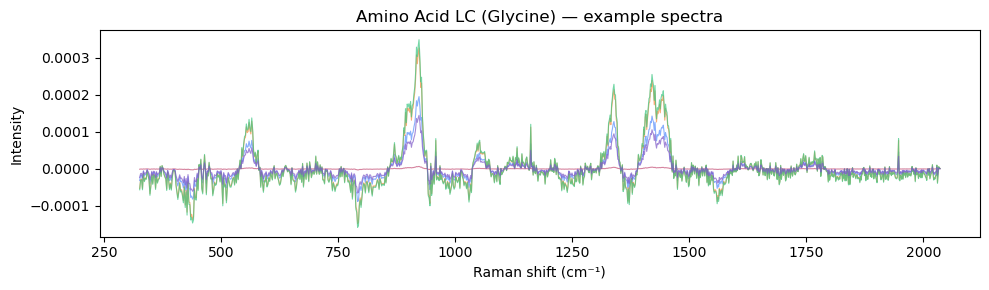

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))
for i in range(min(5, len(dataset.spectra))):
    ax.plot(dataset.raman_shifts, dataset.spectra[i], alpha=0.7, linewidth=0.8)
ax.set_xlabel('Raman shift (cm⁻¹)')
ax.set_ylabel('Intensity')
ax.set_title(f'{dataset.name} — example spectra')
plt.tight_layout()
plt.show()

## 2. Browse the precomputed leaderboard

In [4]:
from raman_bench import Leaderboard

lb = Leaderboard.from_precomputed()
lb.rank()

2026-04-27 09:25:48,997 INFO raman_bench.leaderboard:from_precomputed:139: Loaded precomputed leaderboard: 28 models, 77 datasets


,Rank,model_id,Model,Category,Elo,Score,Avg Rank,Improvability,Train Time s,Infer. s/1K
0,1,AUTOGLUON,"AutoGluon 1.5 (extreme, 4h)",AutoML,1558,0.75,4.8,23.0,1776.3,220.7
1,2,REALTABPFN-V2.5,TabPFN v2.5,Tabular Foundation,1529,0.71,5.5,27.3,89.6,100.8
2,3,TABICL,TabICL,Tabular Foundation,1443,0.62,6.5,33.3,39.9,130.3
3,4,REALTABPFN-V2,TabPFN v2,Tabular Foundation,1402,0.54,8.1,44.0,77.6,146.4
4,5,MITRA,MITRA,Tabular Foundation,1312,0.42,10.3,49.5,827.4,626.5
5,6,ARSENAL,ARSENAL,TS Classification,1240,0.42,10.4,58.3,2876.0,2790.3
6,7,REZERONET,ReZeroNet,Raman-Specific,1133,0.39,10.3,45.2,44.6,23.1
7,8,ROCKET,ROCKET,TS Classification,1244,0.38,10.4,55.5,1270.3,140.5
8,9,TABDPT,TabDPT,Tabular Foundation,1136,0.30,12.5,52.9,12.3,80.2
9,10,LR,Logistic Reg.,Traditional ML,1002,0.27,14.6,53.3,37.2,41.2


,Rank,model,Model,Category,R²,RMSE,MAE,Avg Rank,Score,Improvability %,# Datasets,Elo
0,1,AUTOGLUON,"AutoGluon 1.5 (extreme, 4h)",AutoML,0.67,10.8,8.0,3.6,0.81,11.3,129,1607
1,2,REALTABPFN-V2.5,TabPFN v2.5,Tabular Foundation,0.67,10.4,7.6,3.9,0.77,15.7,129,1580
2,3,REALTABPFN-V2,TabPFN v2,Tabular Foundation,0.60,10.9,7.8,5.7,0.67,25.4,129,1445
3,4,TABICL,TabICL,Tabular Foundation,0.60,10.8,7.8,5.3,0.64,24.0,129,1465
4,5,MITRA,MITRA,Tabular Foundation,0.60,11.2,8.3,7.2,0.51,32.5,129,1338
5,6,TABDPT,TabDPT,Tabular Foundation,-2.20,12.2,8.7,11.7,0.28,41.2,129,1122
6,7,REZERONET,ReZeroNet,Raman-Specific,0.37,11.9,8.9,12.3,0.26,42.3,129,1092
7,8,PLS,PLS,Traditional ML,-0.41,14.1,10.3,14.6,0.21,45.8,129,1040
8,9,REALMLP,RealMLP,Deep Learning,-4.71,12.2,9.0,12.7,0.21,44.0,129,1115
9,10,LR,Logistic Reg.,Traditional ML,-0.72,16.9,12.1,15.1,0.20,48.0,129,1016


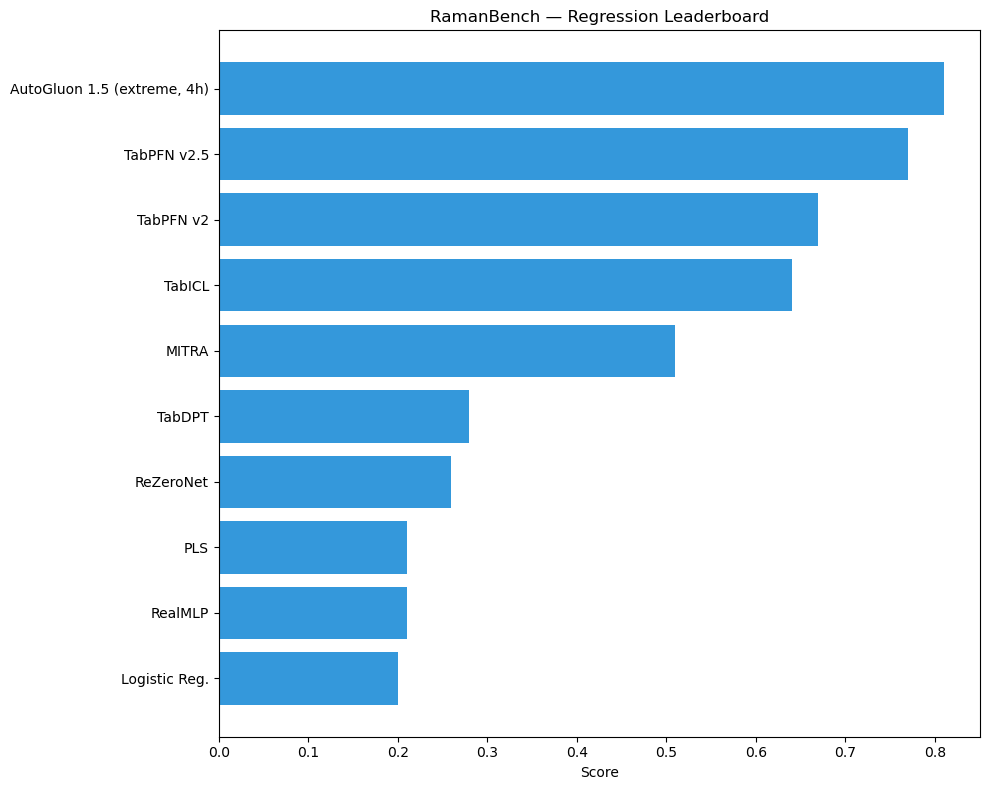

In [5]:
# Regression-only ranking — table
display(lb.rank(task="regression").head(10))

# Regression-only ranking — chart
fig = lb.plot(task="regression", n_top=10)
plt.show()


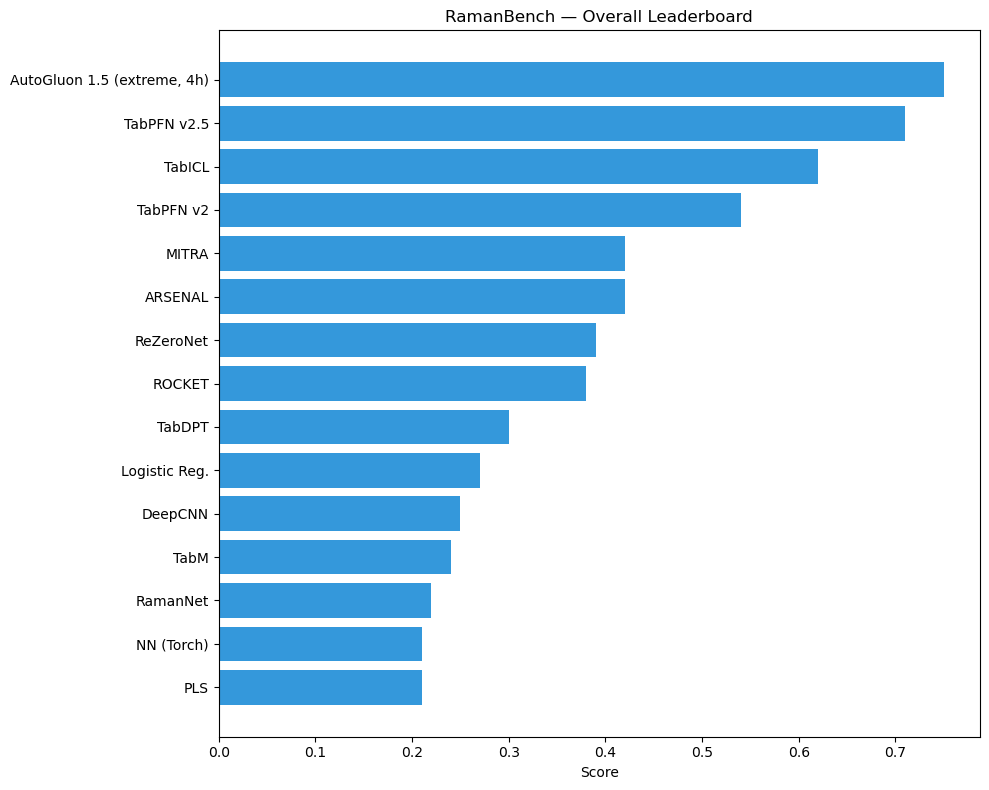

In [6]:
fig = lb.plot(task='overall', n_top=15)
plt.show()

## Next steps

- **`02_benchmark_new_model.ipynb`** — evaluate your own model
- **`03_explore_results.ipynb`** — deep dive into per-dataset metrics
- **`04_contribute_dataset.ipynb`** — contribute a new dataset
- **[Live Leaderboard](https://huggingface.co/spaces/ml-lab-htw/RamanBench)** — interactive results explorer